In [34]:
import pandas as pd
import numpy as np

# Utils


In [35]:
def round_unc(value, uncertainty, cutoff=2, extract_magnitude=False):
    scalar_input = np.isscalar(value)

    value = np.atleast_1d(value).astype(float)
    uncertainty = np.atleast_1d(uncertainty).astype(float)

    exp = np.floor(np.log10(np.abs(uncertainty)))
    first_digit = (uncertainty / 10**exp).astype(int)
    sigs = np.where(first_digit <= cutoff, 2, 1)

    rounding_decimals = (-exp + (sigs - 1)).astype(int)
    rounded_uncertainty = (
        np.round(uncertainty * 10.0**rounding_decimals) / 10.0**rounding_decimals
    )

    decimals = (-np.floor(np.log10(rounded_uncertainty)) + (sigs - 1)).astype(int)
    rounded_value = np.round(value * 10.0**decimals) / 10.0**decimals

    if extract_magnitude:
        exponent = np.floor(np.log10(np.abs(rounded_value))).astype(int)
        mantissa_value = rounded_value / 10.0**exponent
        mantissa_uncertainty = rounded_uncertainty / 10.0**exponent

        if scalar_input:
            return mantissa_value[0], mantissa_uncertainty[0], exponent[0]
        return mantissa_value, mantissa_uncertainty, exponent

    if scalar_input:
        return rounded_value[0], rounded_uncertainty[0]
    return rounded_value, rounded_uncertainty

# DF Processing


In [36]:
df = pd.read_csv("results.csv")
df

,current_a,magnetic_field_g,field_uncertainty_g,sho_period_1_s,sho_period_2_s,sho_period_3_s,sho_period_4_s,sho_period_5_s,half_precession_period_s,min_spin_frequency_rpm,max_spin_frequency_rpm
0,-2.00,13.9,0.2,5.62,5.60,5.55,5.49,5.79,11.55,996.0,1038.0
1,-1.75,11.7,0.1,6.35,5.94,6.15,6.38,6.36,12.09,923.3,1021.0
2,-1.50,10.1,0.2,6.56,6.74,6.54,7.03,6.70,15.21,888.3,968.4
3,-1.25,8.3,0.1,7.91,7.32,7.64,7.41,7.27,21.62,994.5,1081.0
4,-1.00,6.4,1.0,8.40,8.13,8.29,8.21,8.28,23.43,773.6,846.4


In [37]:
period_cols = [f"sho_period_{i}_s" for i in range(1, 5 + 1)]
period_cols

['sho_period_1_s',
 'sho_period_2_s',
 'sho_period_3_s',
 'sho_period_4_s',
 'sho_period_5_s']

In [38]:
df["sho_period_avg"] = (df[period_cols].mean(axis=1)) / 5.5
df["sho_period_unc"] = (df[period_cols] / 5.5).std(axis=1) / np.sqrt(5)

In [39]:
df["pos_current"] = df["current_a"].abs()

Prop the spin period uncertainty

$$
T = \frac{1}{f}
$$

$$
\frac{\partial T}{\partial f} = \frac{-1}{f^2}
$$

$$
\delta T = \frac{1}{f^2} \delta f
$$


In [40]:
df["spin_freq_lower"] = df["min_spin_frequency_rpm"] / 60
df["spin_freq_upper"] = df["max_spin_frequency_rpm"] / 60
df["spin_freq_unc"] = (df["spin_freq_upper"] - df["spin_freq_lower"]) / 2
df["spin_freq_avg"] = (df["spin_freq_lower"] + df["spin_freq_upper"]) / 2
df["precession_period"] = df["half_precession_period_s"] * 2
df["spin_period_avg"] = 1 / df["spin_freq_avg"]
df["spin_period_unc"] = (1 / df["spin_freq_avg"] ** 2) * df["spin_freq_unc"]

In [41]:
df.columns

Index(['current_a', 'magnetic_field_g', 'field_uncertainty_g',
       'sho_period_1_s', 'sho_period_2_s', 'sho_period_3_s', 'sho_period_4_s',
       'sho_period_5_s', 'half_precession_period_s', 'min_spin_frequency_rpm',
       'max_spin_frequency_rpm', 'sho_period_avg', 'sho_period_unc',
       'pos_current', 'spin_freq_lower', 'spin_freq_upper', 'spin_freq_unc',
       'spin_freq_avg', 'precession_period', 'spin_period_avg',
       'spin_period_unc'],
      dtype='object')

In [42]:
df["magnetic_field_g"]
df["magnetic_field_T"] = df["magnetic_field_g"] * 1e-4

# General Values


In [43]:
# Mass of ball: 183.0 pm 0.1 g
# Radius of ball: 28.5 mm pm 2 mm

m = 183.0 * 1e-3  # kg
r = 28.5 * 1e-3  # m
m_unc = 0.1 * 1e-3  # kg
r_unc = 1 * 1e-3  # m
B_unc = 0.1  # g
B_unc *= 1e-4  # g -> T
half_precession_unc = 0.5  # s
precession_unc = 2 * half_precession_unc


def prop_I_unc(m, m_unc, r, r_unc, I):
    vals = np.array(
        [
            m_unc / m,
            2 * (r_unc / r),
        ]
    )

    return I * np.sqrt((vals**2).sum())


I = (2 / 5) * m * r**2  # moment of inertia
I_unc = prop_I_unc(m, m_unc, r, r_unc, I)
print(I, I_unc)

5.94567e-05 4.1725264960333086e-06


# SDOM Plots


In [44]:
df["spin_period_avg"]

0    0.058997
1    0.061719
2    0.064631
3    0.057817
4    0.074074
Name: spin_period_avg, dtype: float64

In [45]:
df["precession_period"]

0    23.10
1    24.18
2    30.42
3    43.24
4    46.86
Name: precession_period, dtype: float64

In [46]:
I

5.94567e-05

In [47]:
# For both experiments
# Compute the dipole moment pointwise using formulas
df["mu_sho"] = (I / df["magnetic_field_T"]) * (2 * np.pi / df["sho_period_avg"]) ** 2
df["mu_prec"] = (I / df["magnetic_field_T"]) * (
    (2 * np.pi) ** 2 / (df["precession_period"] * df["spin_period_avg"])
)

# Find the mean
mu_sho_mean = df["mu_sho"].mean()
mu_prec_mean = df["mu_prec"].mean()

# Find the SDOM
mu_sho_sdom = df["mu_sho"].std() / np.sqrt(len(df))
mu_prec_sdom = df["mu_prec"].std() / np.sqrt(len(df))

In [48]:
def prop_sho_mu(I, I_unc, B, B_unc, T, T_unc, mu):
    term1 = (I_unc / I) ** 2
    term2 = (B_unc / B) ** 2
    term3 = (2 * T_unc / T) ** 2

    return mu * np.sqrt(term1 + term2 + term3)


def prop_prec_mu(I, I_unc, B, B_unc, Ts, Ts_unc, Tp, Tp_unc, mu):
    term1 = (I_unc / I) ** 2
    term2 = (B_unc / B) ** 2
    term3 = (2 * Ts_unc / Ts) ** 2
    term4 = (2 * Tp_unc / Tp) ** 2

    return mu * np.sqrt(term1 + term2 + term3 + term4)

In [49]:
df["mu_prec_unc"] = prop_prec_mu(
    I=I,
    I_unc=I_unc,
    B=df["magnetic_field_T"],
    B_unc=B_unc,
    Ts=df["spin_period_avg"],
    Ts_unc=df["spin_period_unc"],
    Tp=df["precession_period"],
    Tp_unc=precession_unc,
    mu=df["mu_prec"],
)

df["mu_sho_unc"] = prop_sho_mu(
    I=I,
    I_unc=I_unc,
    B=df["magnetic_field_T"],
    B_unc=B_unc,
    T=df["sho_period_avg"],
    T_unc=df["sho_period_unc"],
    mu=df["mu_sho"],
)


In [50]:
import matplotlib.pyplot as plt

<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:74: SyntaxWarning: invalid escape sequence '\p'
<>:33: SyntaxWarning: invalid escape sequence '\p'
<>:74: SyntaxWarning: invalid escape sequence '\p'
/var/folders/ly/g3q4h9f54w5517k2glh05n7c0000gn/T/ipykernel_94165/2668882148.py:33: SyntaxWarning: invalid escape sequence '\p'
  [f"Mean = ${mu_sho_mean_rounded} \pm {mu_sho_sdom_rounded}$ A·m²", r"1$\sigma$"],
/var/folders/ly/g3q4h9f54w5517k2glh05n7c0000gn/T/ipykernel_94165/2668882148.py:74: SyntaxWarning: invalid escape sequence '\p'
  [f"Mean = ${mu_prec_mean_rounded} \pm {mu_prec_sdom_rounded}$ A·m²", r"1$\sigma$"],


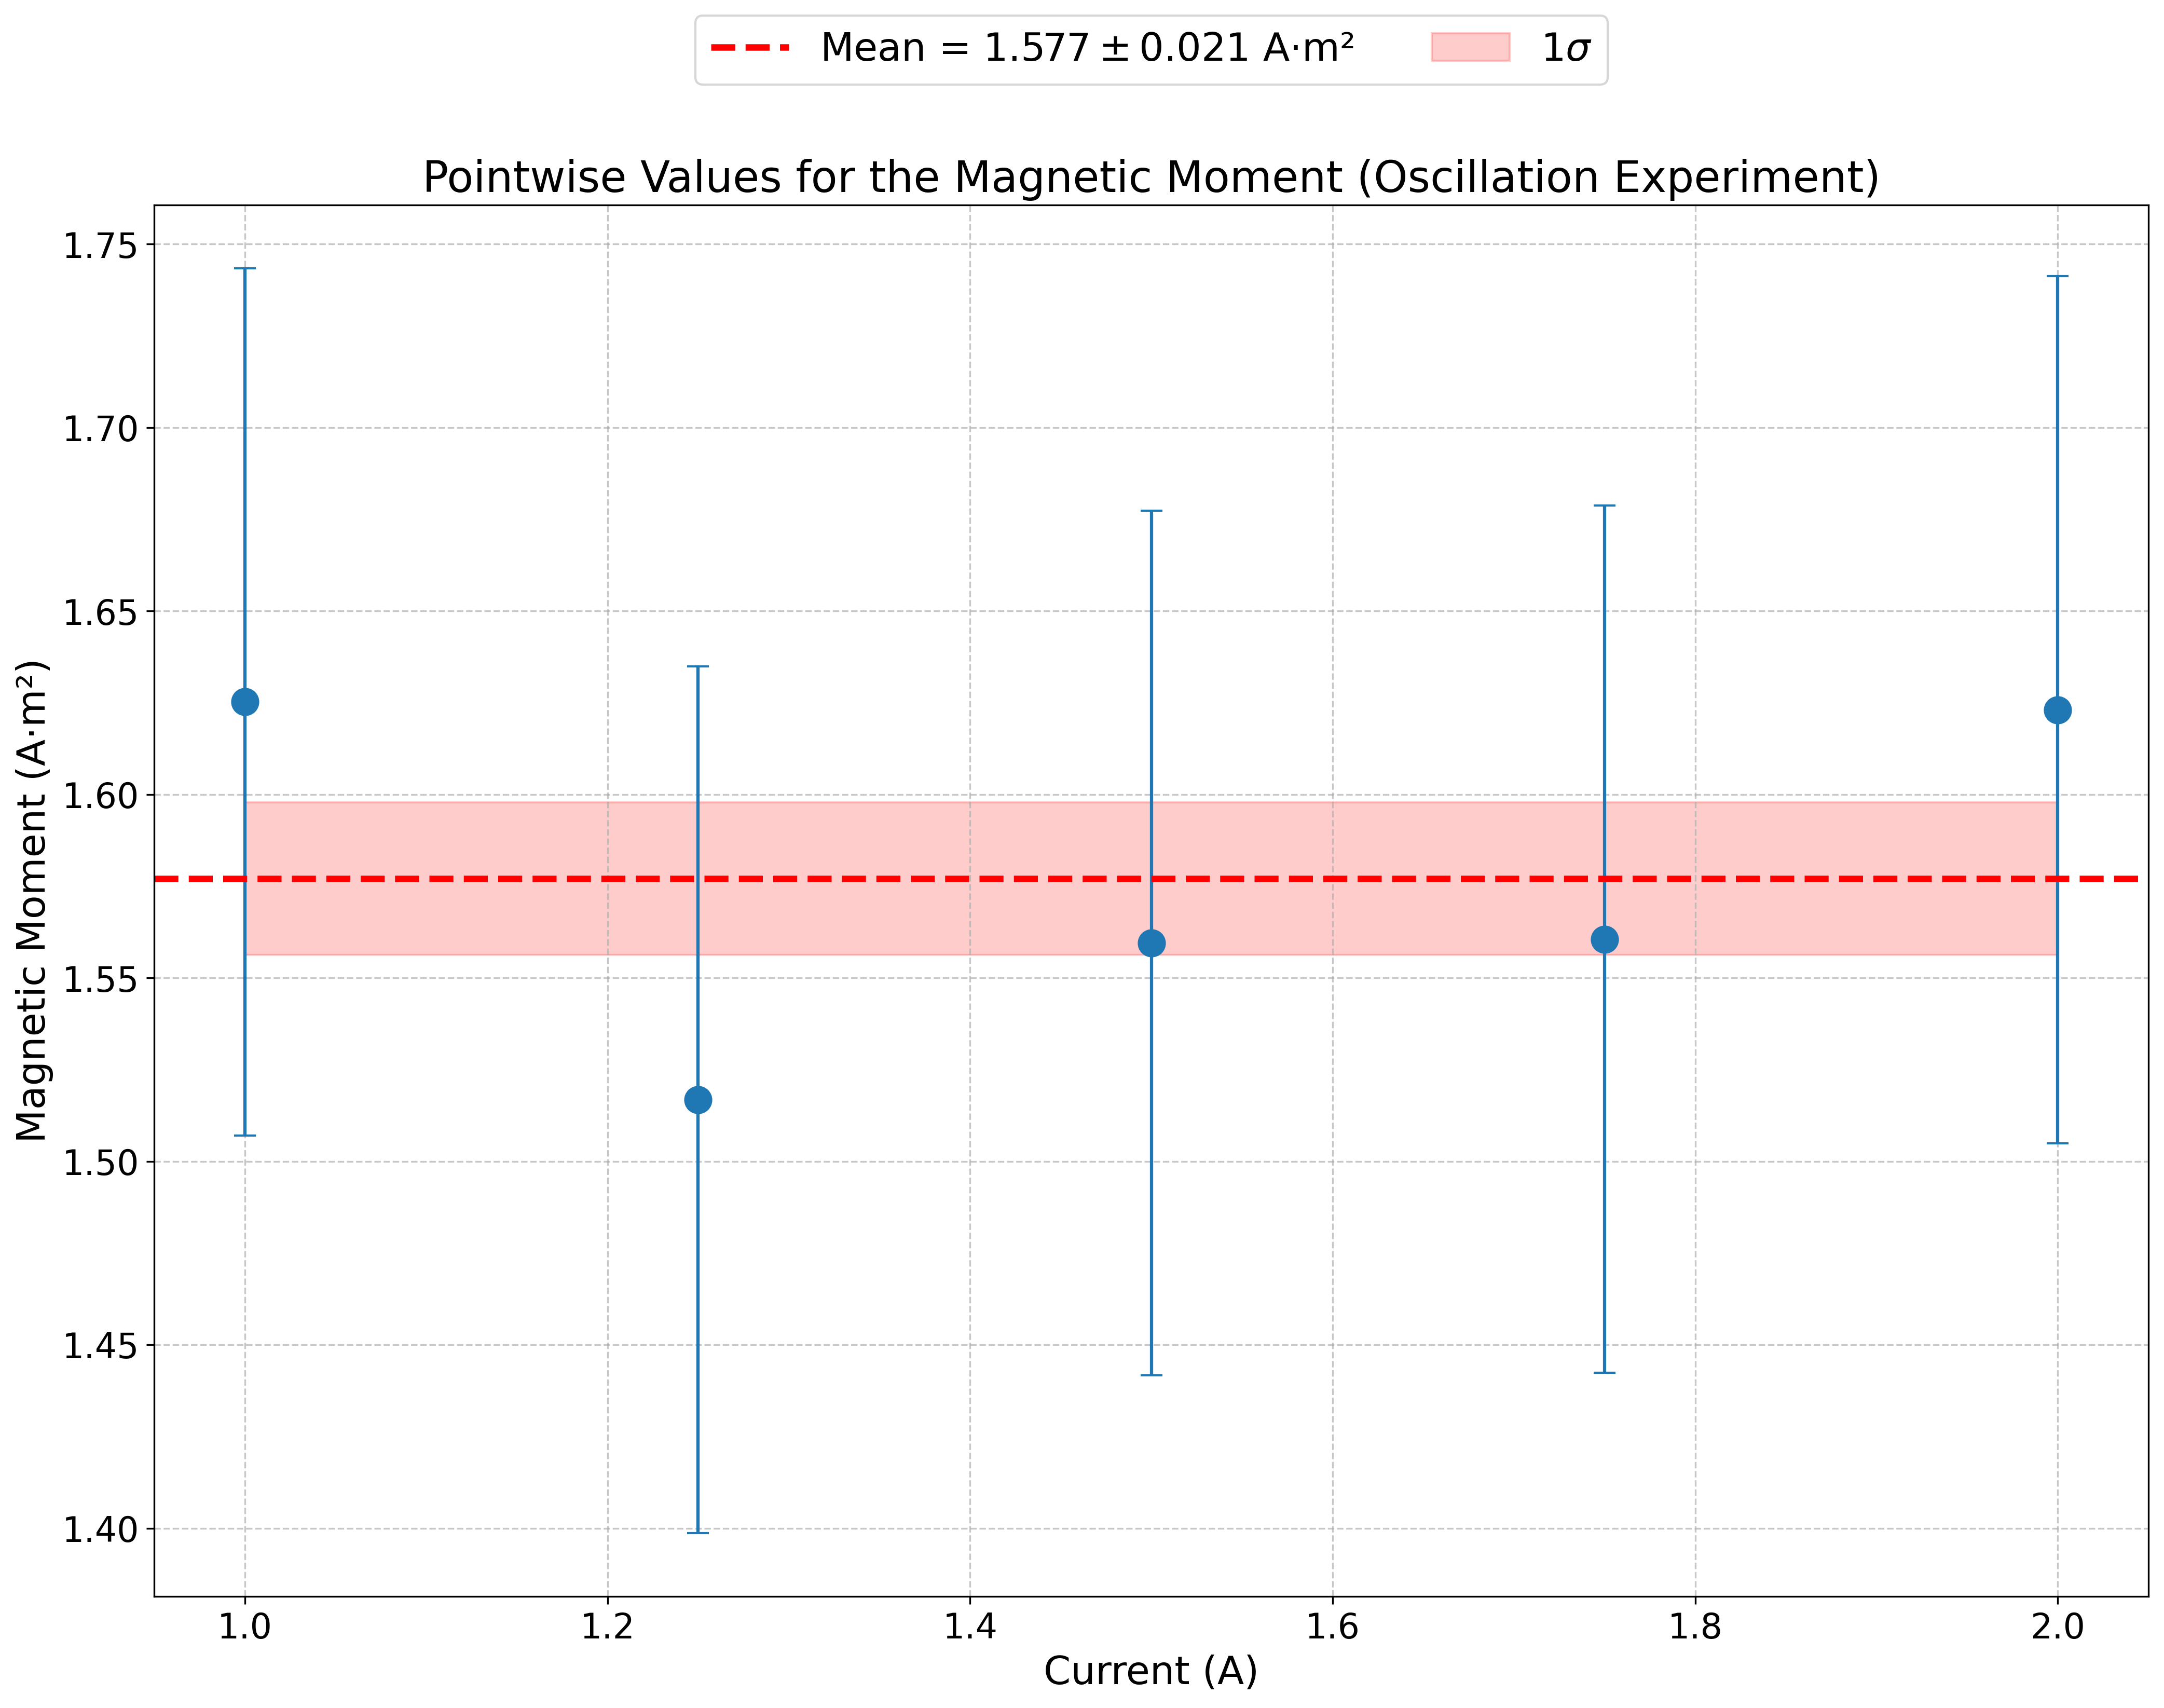

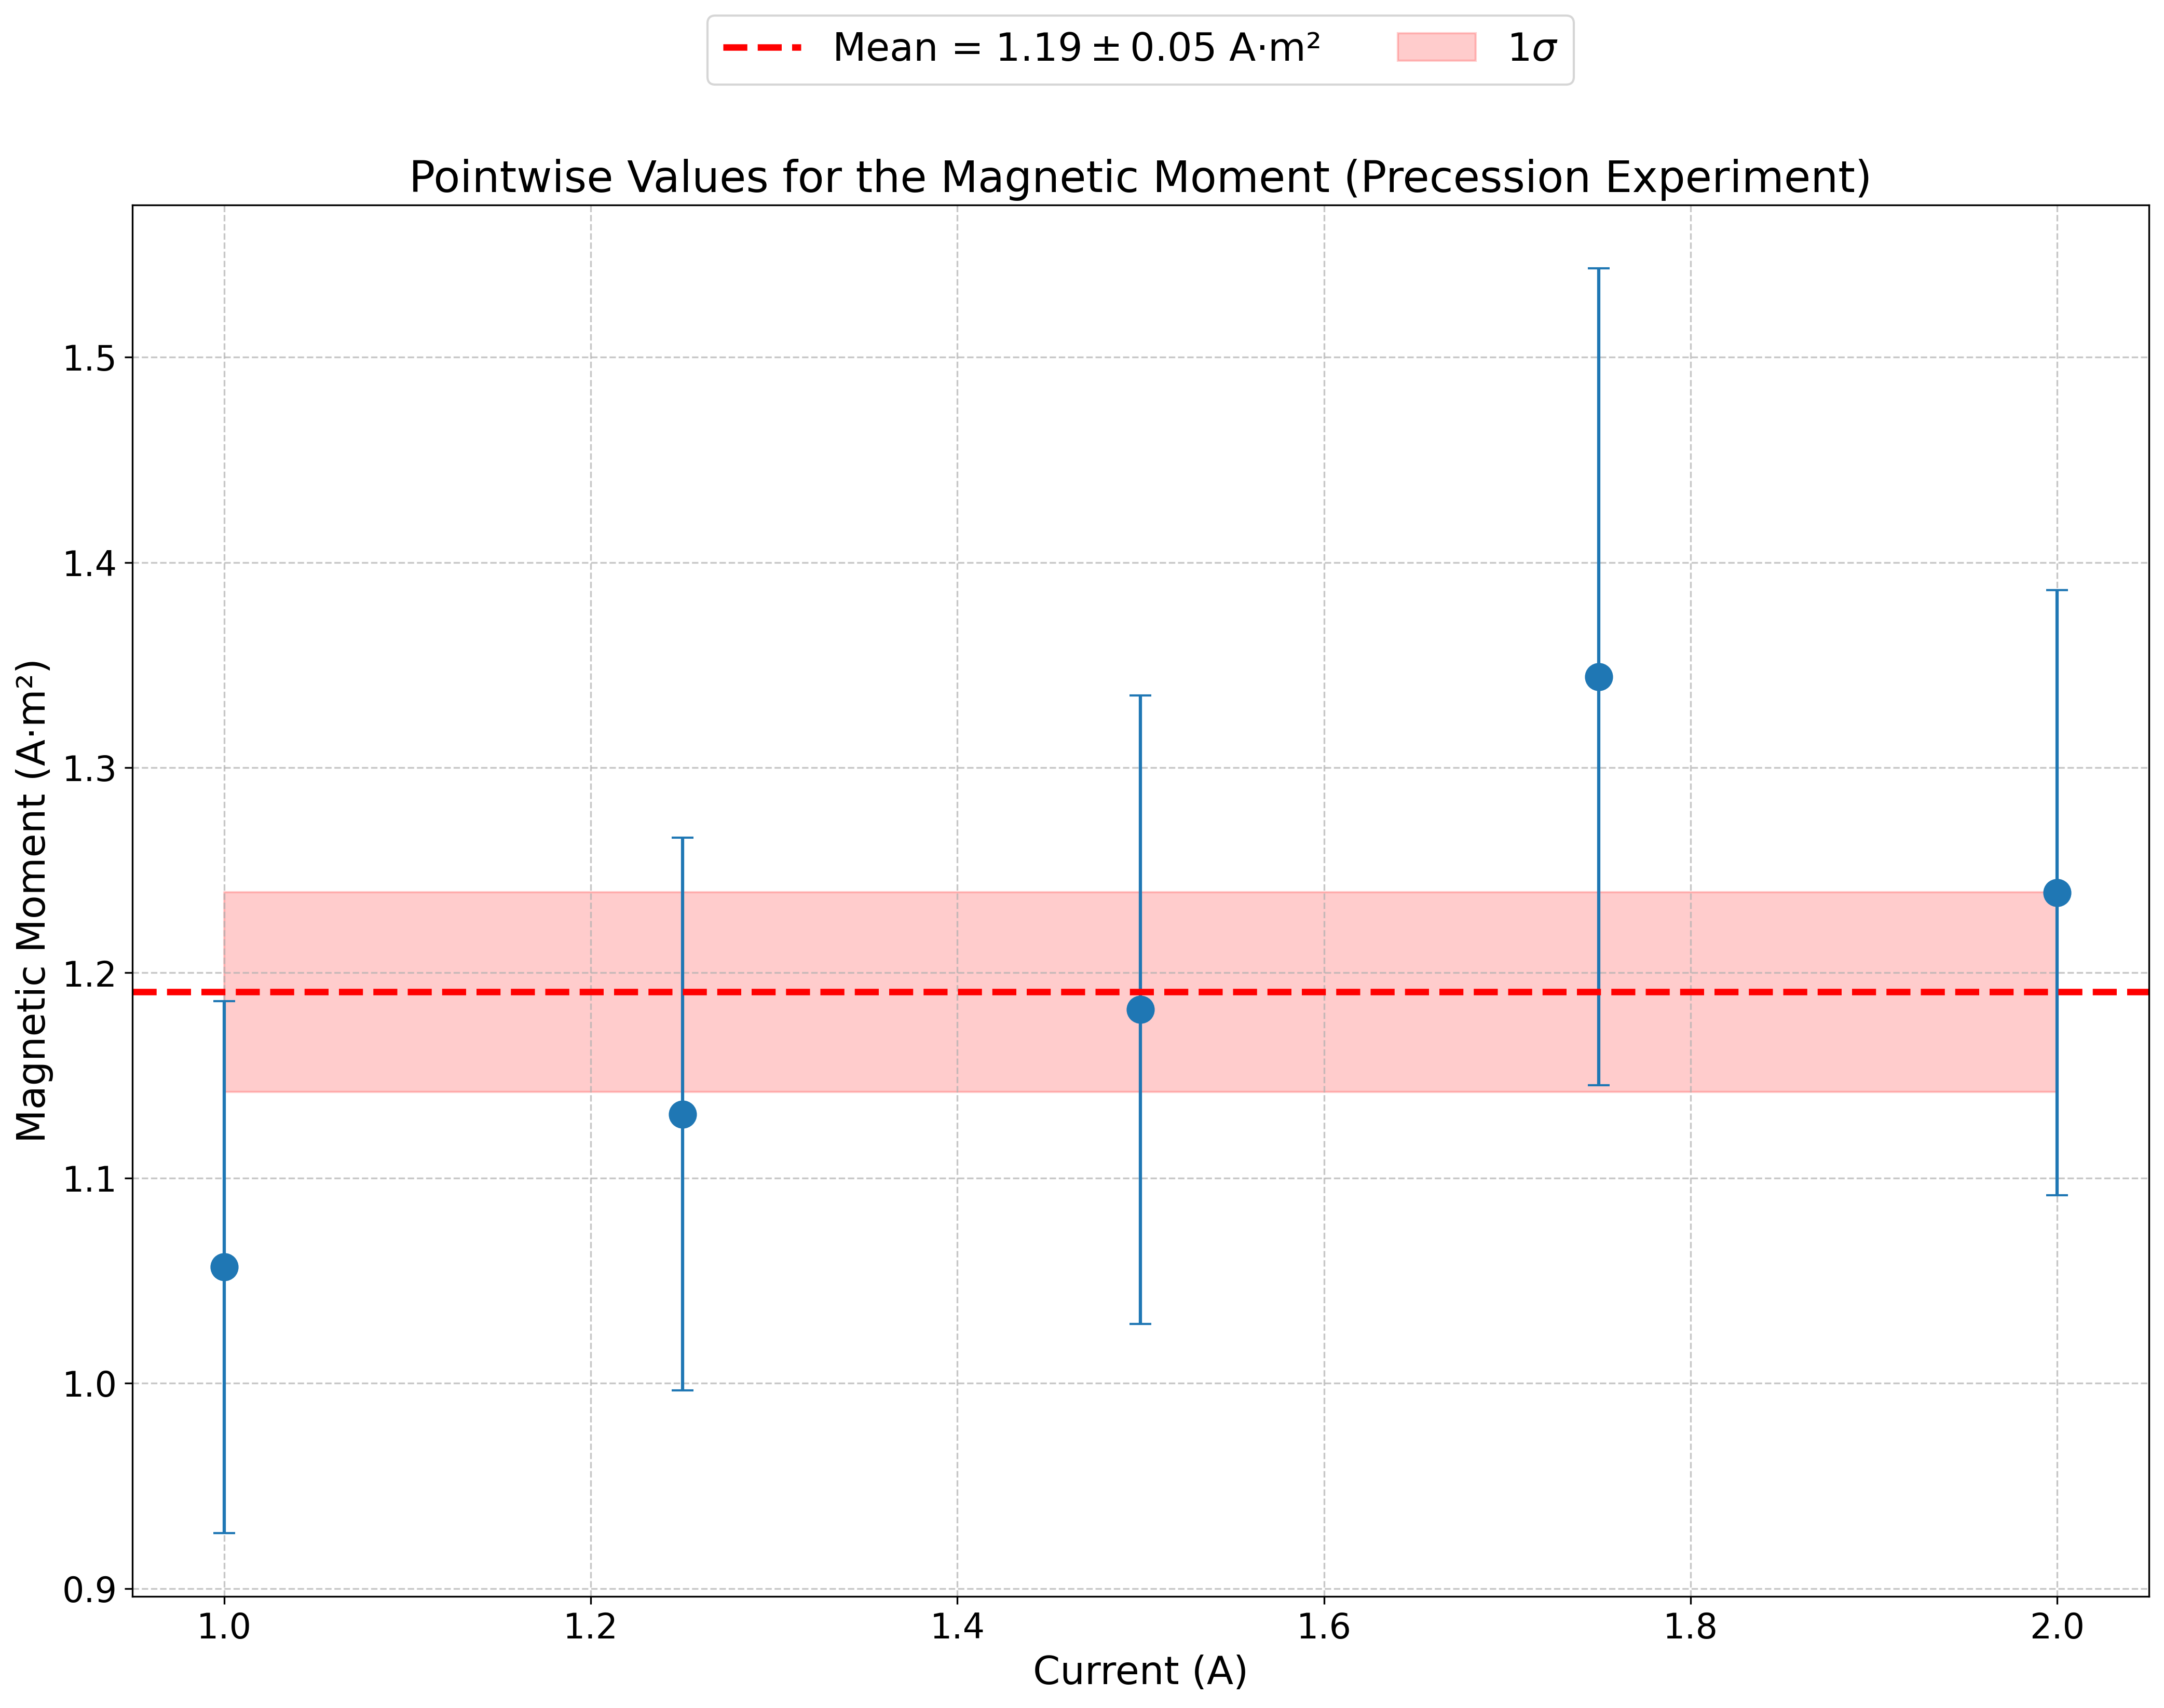

In [51]:
# Create SDOM plots for mu values from SHO and Precession
plt.figure(figsize=(14, 11), dpi=300)  # Even larger figure size

# SHO mu plot
plt.errorbar(
    df["pos_current"],
    df["mu_sho"],
    yerr=df["mu_sho_unc"],
    fmt="o",
    capsize=5,
    label="SHO Method",
    markersize=12,  # Larger marker
)
plt.axhline(y=mu_sho_mean, color="r", linestyle="--", label="Mean", linewidth=3)
plt.fill_between(
    df["pos_current"],
    mu_sho_mean - mu_sho_sdom,
    mu_sho_mean + mu_sho_sdom,
    alpha=0.2,
    color="r",
)
mu_sho_mean_rounded, mu_sho_sdom_rounded = round_unc(mu_sho_mean, mu_sho_sdom)
plt.title(
    "Pointwise Values for the Magnetic Moment (Oscillation Experiment)",
    fontsize=20,
    ha="center",
)
plt.xlabel("Current (A)", fontsize=18)
plt.ylabel("Magnetic Moment (A·m²)", fontsize=18)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis="both", which="major", labelsize=16)  # Even larger tick label size
plt.legend(
    [f"Mean = ${mu_sho_mean_rounded} \pm {mu_sho_sdom_rounded}$ A·m²", r"1$\sigma$"],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=2,
    fontsize=18,  # Increased legend font size
)
plt.tight_layout()
plt.savefig("mu_sho_plots.png", dpi=300)
plt.show()

plt.figure(figsize=(14, 11), dpi=300)  # Even larger figure size

# Precession mu plot
plt.errorbar(
    df["pos_current"],
    df["mu_prec"],
    yerr=df["mu_prec_unc"],
    fmt="o",
    capsize=5,
    label="Precession Method",
    markersize=12,  # Larger marker
)
plt.axhline(y=mu_prec_mean, color="r", linestyle="--", label="Mean", linewidth=3)
plt.fill_between(
    df["pos_current"],
    mu_prec_mean - mu_prec_sdom,
    mu_prec_mean + mu_prec_sdom,
    alpha=0.2,
    color="r",
)
mu_prec_mean_rounded, mu_prec_sdom_rounded = round_unc(mu_prec_mean, mu_prec_sdom)
plt.title(
    "Pointwise Values for the Magnetic Moment (Precession Experiment)",
    fontsize=20,
    ha="center",
)
plt.xlabel("Current (A)", fontsize=18)
plt.ylabel("Magnetic Moment (A·m²)", fontsize=18)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tick_params(axis="both", which="major", labelsize=16)  # Even larger tick label size
plt.legend(
    [f"Mean = ${mu_prec_mean_rounded} \pm {mu_prec_sdom_rounded}$ A·m²", r"1$\sigma$"],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=2,
    fontsize=18,  # Increased legend font size
)
plt.tight_layout()
plt.savefig("mu_prec_plots.png", dpi=300)
plt.show()


# Linear Regression Plots


In [52]:
df.columns

Index(['current_a', 'magnetic_field_g', 'field_uncertainty_g',
       'sho_period_1_s', 'sho_period_2_s', 'sho_period_3_s', 'sho_period_4_s',
       'sho_period_5_s', 'half_precession_period_s', 'min_spin_frequency_rpm',
       'max_spin_frequency_rpm', 'sho_period_avg', 'sho_period_unc',
       'pos_current', 'spin_freq_lower', 'spin_freq_upper', 'spin_freq_unc',
       'spin_freq_avg', 'precession_period', 'spin_period_avg',
       'spin_period_unc', 'magnetic_field_T', 'mu_sho', 'mu_prec',
       'mu_prec_unc', 'mu_sho_unc'],
      dtype='object')

In [53]:
def prop_T_term_unc(T, T_unc):
    return ((2 * np.pi) / T) ** 2 * (2 * T_unc / T)


def prop_Ts_Tp_term_unc(Ts, Ts_unc, Tp, Tp_unc):
    term1 = 4 * (Ts_unc / Ts) ** 2
    term2 = 4 * (Tp_unc / Tp) ** 2

    return (2 * np.pi) ** 2 / (Ts * Tp) * np.sqrt(term1 + term2)


def prop_B_term_unc(B, B_unc, I, I_unc):
    return (B / I) * np.sqrt(((B_unc / B) ** 2 + (I_unc / I) ** 2))


df["2_pi_upon_T_sq"] = (2 * np.pi / df["sho_period_avg"]) ** 2
df["2_pi_upon_T_sq_unc"] = prop_T_term_unc(
    T=df["sho_period_avg"], T_unc=df["sho_period_unc"]
)

df["2_pi_upon_Tp_Ts_sq"] = (2 * np.pi) ** 2 / (
    df["precession_period"] * df["spin_period_avg"]
)

df["2_pi_upon_Tp_Ts_sq_unc"] = prop_Ts_Tp_term_unc(
    Ts=df["spin_period_avg"],
    Ts_unc=df["spin_period_unc"],
    Tp=df["precession_period"],
    Tp_unc=precession_unc,
)


df["B_upon_I"] = df["magnetic_field_T"] / I
df["B_upon_I_unc"] = prop_B_term_unc(
    B=df["magnetic_field_T"],
    B_unc=B_unc,
    I=I,
    I_unc=I_unc,
)


Slope: 1.6325555820077162
Intercept: -0.9142443194334966
R-value: 0.9960549316516661
P-value: 0.0002972750700544565
Standard Error: 0.0839725939821801


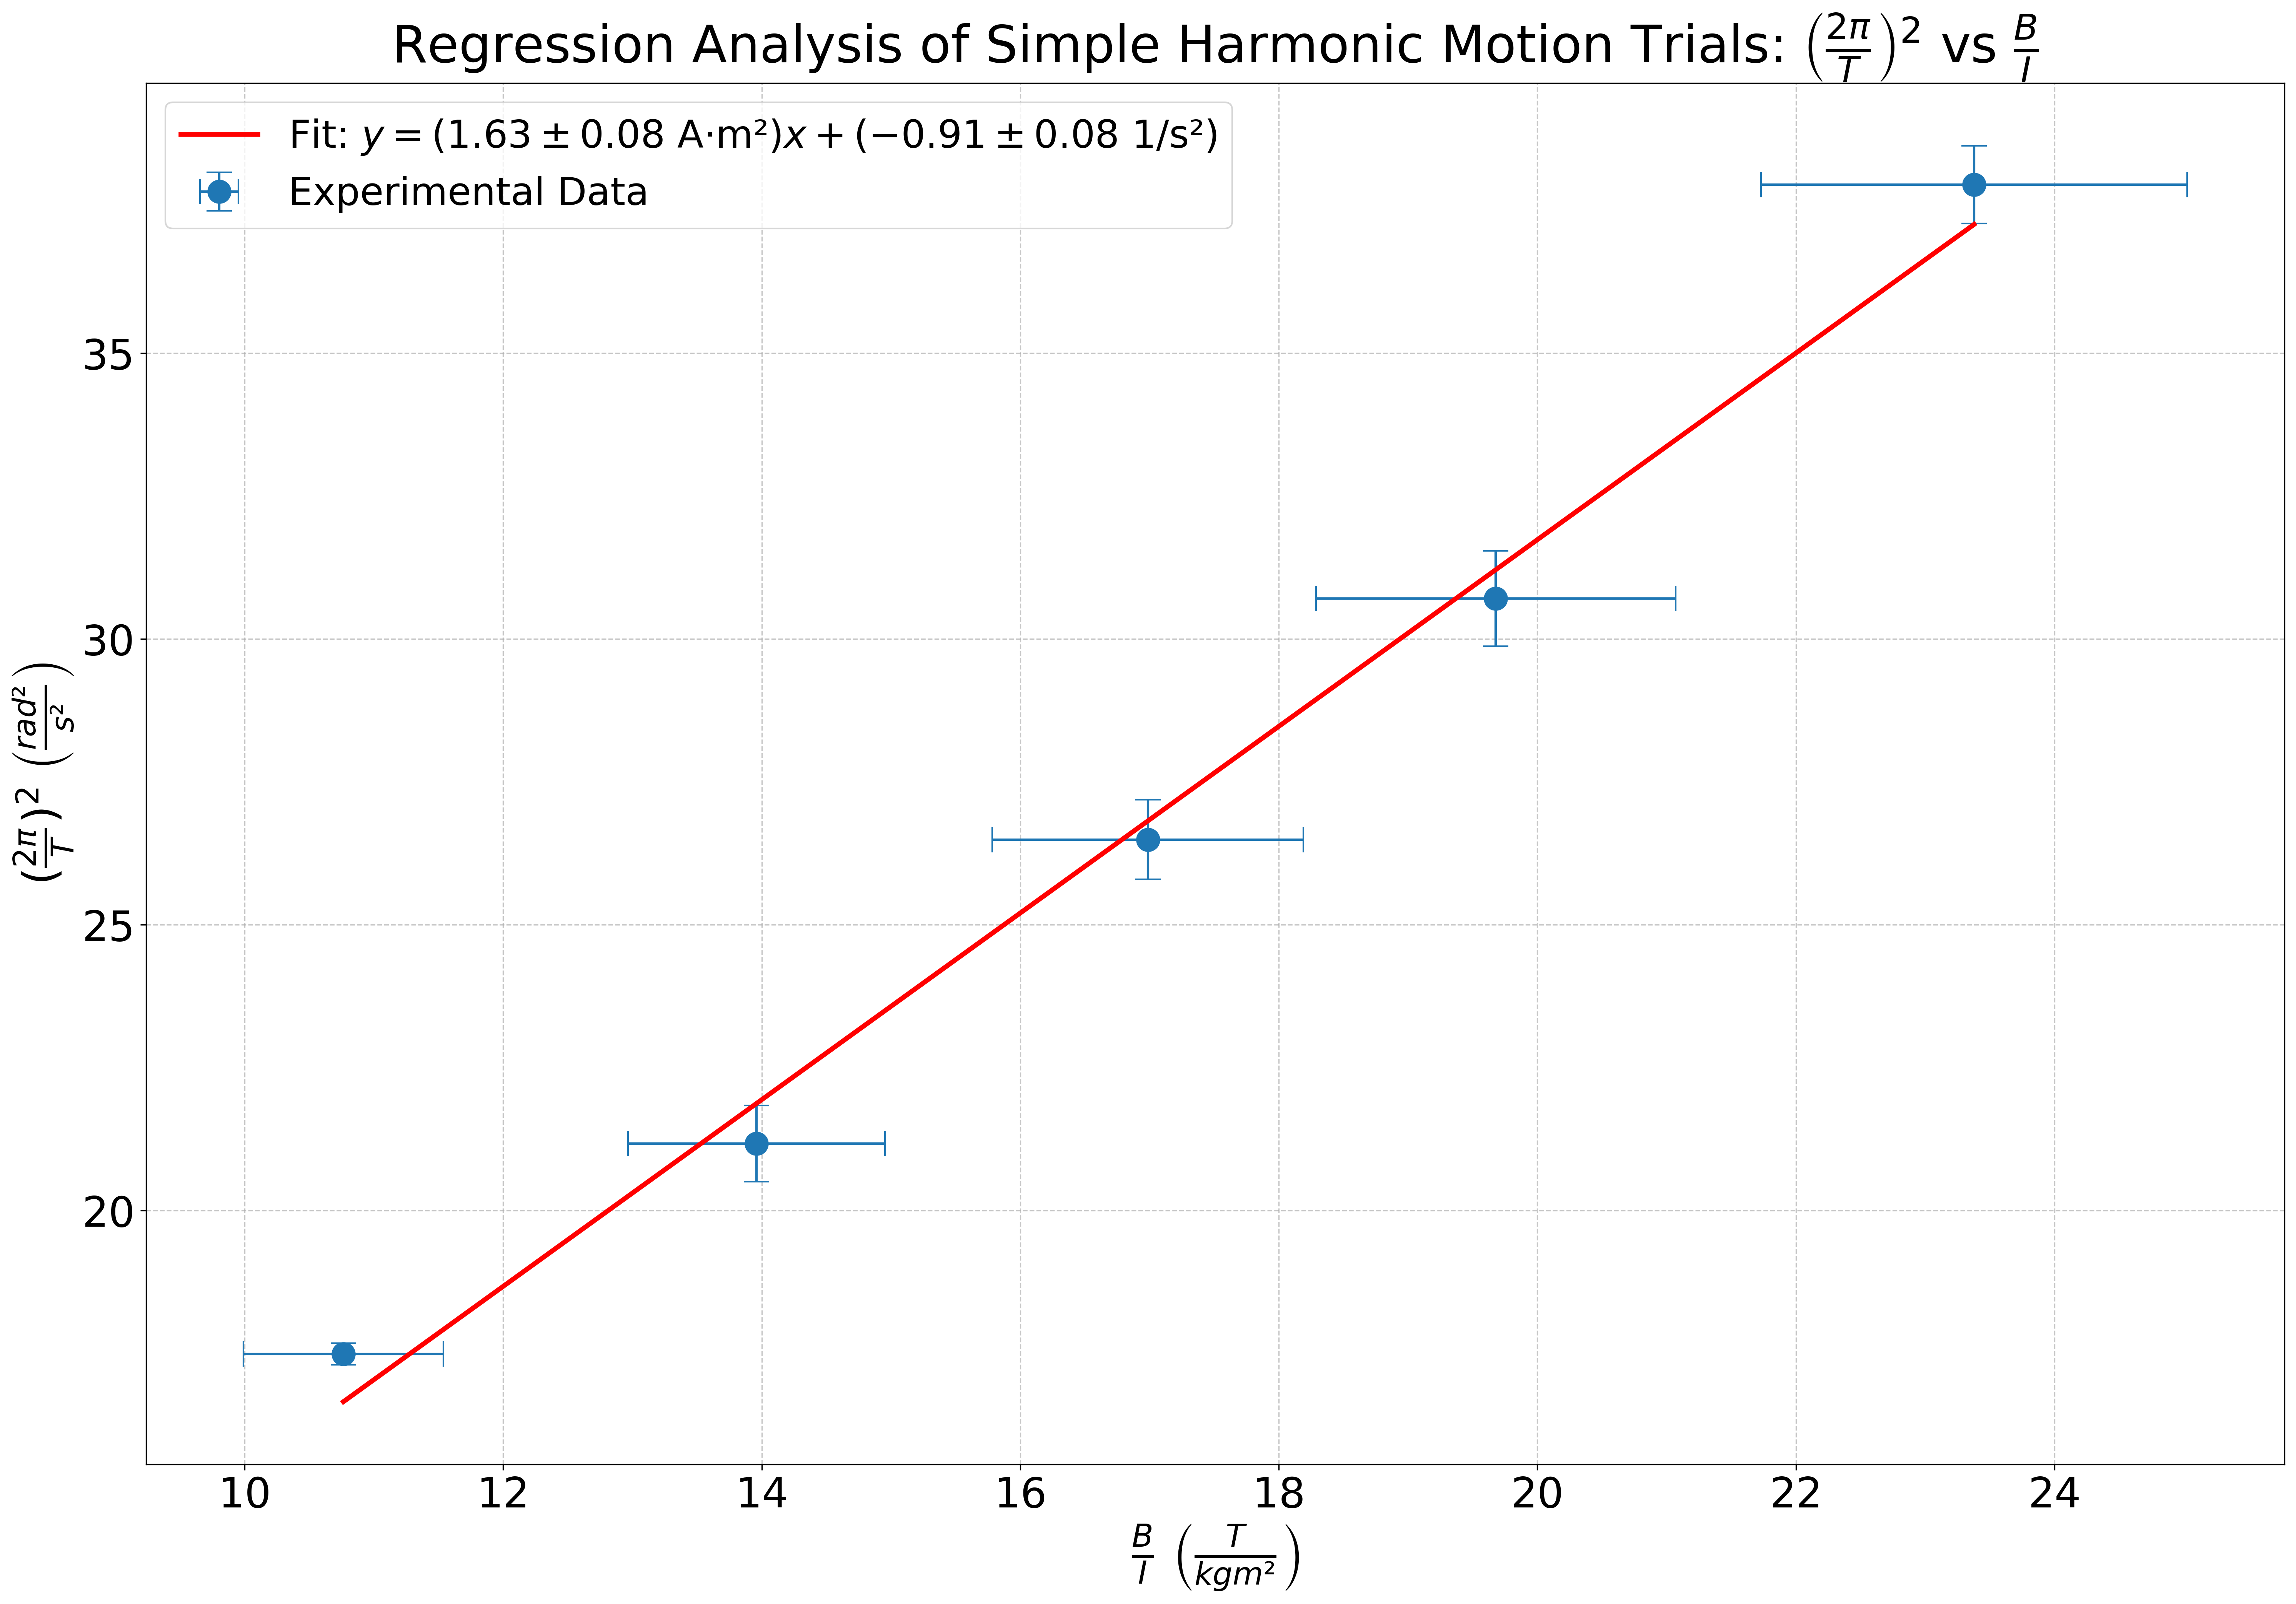

In [54]:
from scipy import stats

# Linear Regression Plot with Uncertainties
plt.figure(figsize=(20, 14), dpi=300)  # Further increased figure size and resolution

# Plot data points with error bars
plt.errorbar(
    df["B_upon_I"],
    df["2_pi_upon_T_sq"],
    xerr=df["B_upon_I_unc"],
    yerr=df["2_pi_upon_T_sq_unc"],
    fmt="o",
    capsize=8,
    label="Experimental Data",
    markersize=14,  # Further increased marker size
)

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df["B_upon_I"], df["2_pi_upon_T_sq"]
)
print("Slope:", slope)
print("Intercept:", intercept)
print("R-value:", r_value)
print("P-value:", p_value)
print("Standard Error:", std_err)

# Create line of best fit
x_line = np.linspace(df["B_upon_I"].min(), df["B_upon_I"].max(), 100)
y_line = slope * x_line + intercept

# Plot line of best fit
plt.plot(x_line, y_line, "r-", label="Linear Regression", linewidth=3)

# Round slope and intercept uncertainties
slope_rounded, slope_unc_rounded = round_unc(slope, std_err)
intercept_rounded, intercept_unc_rounded = round_unc(intercept, std_err)

# Create legend with equation
plt.title(
    rf"Regression Analysis of Simple Harmonic Motion Trials: $\left(\frac{{2\pi}}{{T}}\right)^2$ vs $\frac{{B}}{{I}}$",
    fontsize=32,  # Increased title font size
)
plt.xlabel(
    rf"$\frac{{B}}{{I}}$ $\left (\frac{{T}}{{kg m²}}\right)$", fontsize=28
)  # Increased x-label font size
plt.ylabel(
    rf"$(\frac{{2\pi}}{{T}})^2$ $\left (\frac{{rad²}}{{s²}}\right)$",
    fontsize=28,  # Increased y-label font size
)
plt.legend(
    [
        rf"Fit: $y = ({slope_rounded} \pm {slope_unc_rounded} \text{{ A·m²}})x + ({intercept_rounded} \pm {intercept_unc_rounded} \text{{ 1/s²}})$",
        "Experimental Data",
    ],
    fontsize=24,  # Increased legend font size
    loc="best",
)

plt.tick_params(
    axis="both", which="major", labelsize=26
)  # Increased tick label size from 22 to 26
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(
    "simple_harmonic_motion_trials.png", dpi=400
)  # Further increased save resolution
plt.show()


Slope: 1.4711963061920228
Intercept: -4.408730083660636
R-value: 0.9880379526154718
P-value: 0.0015676941643108099
Standard Error: 0.13257189559046842


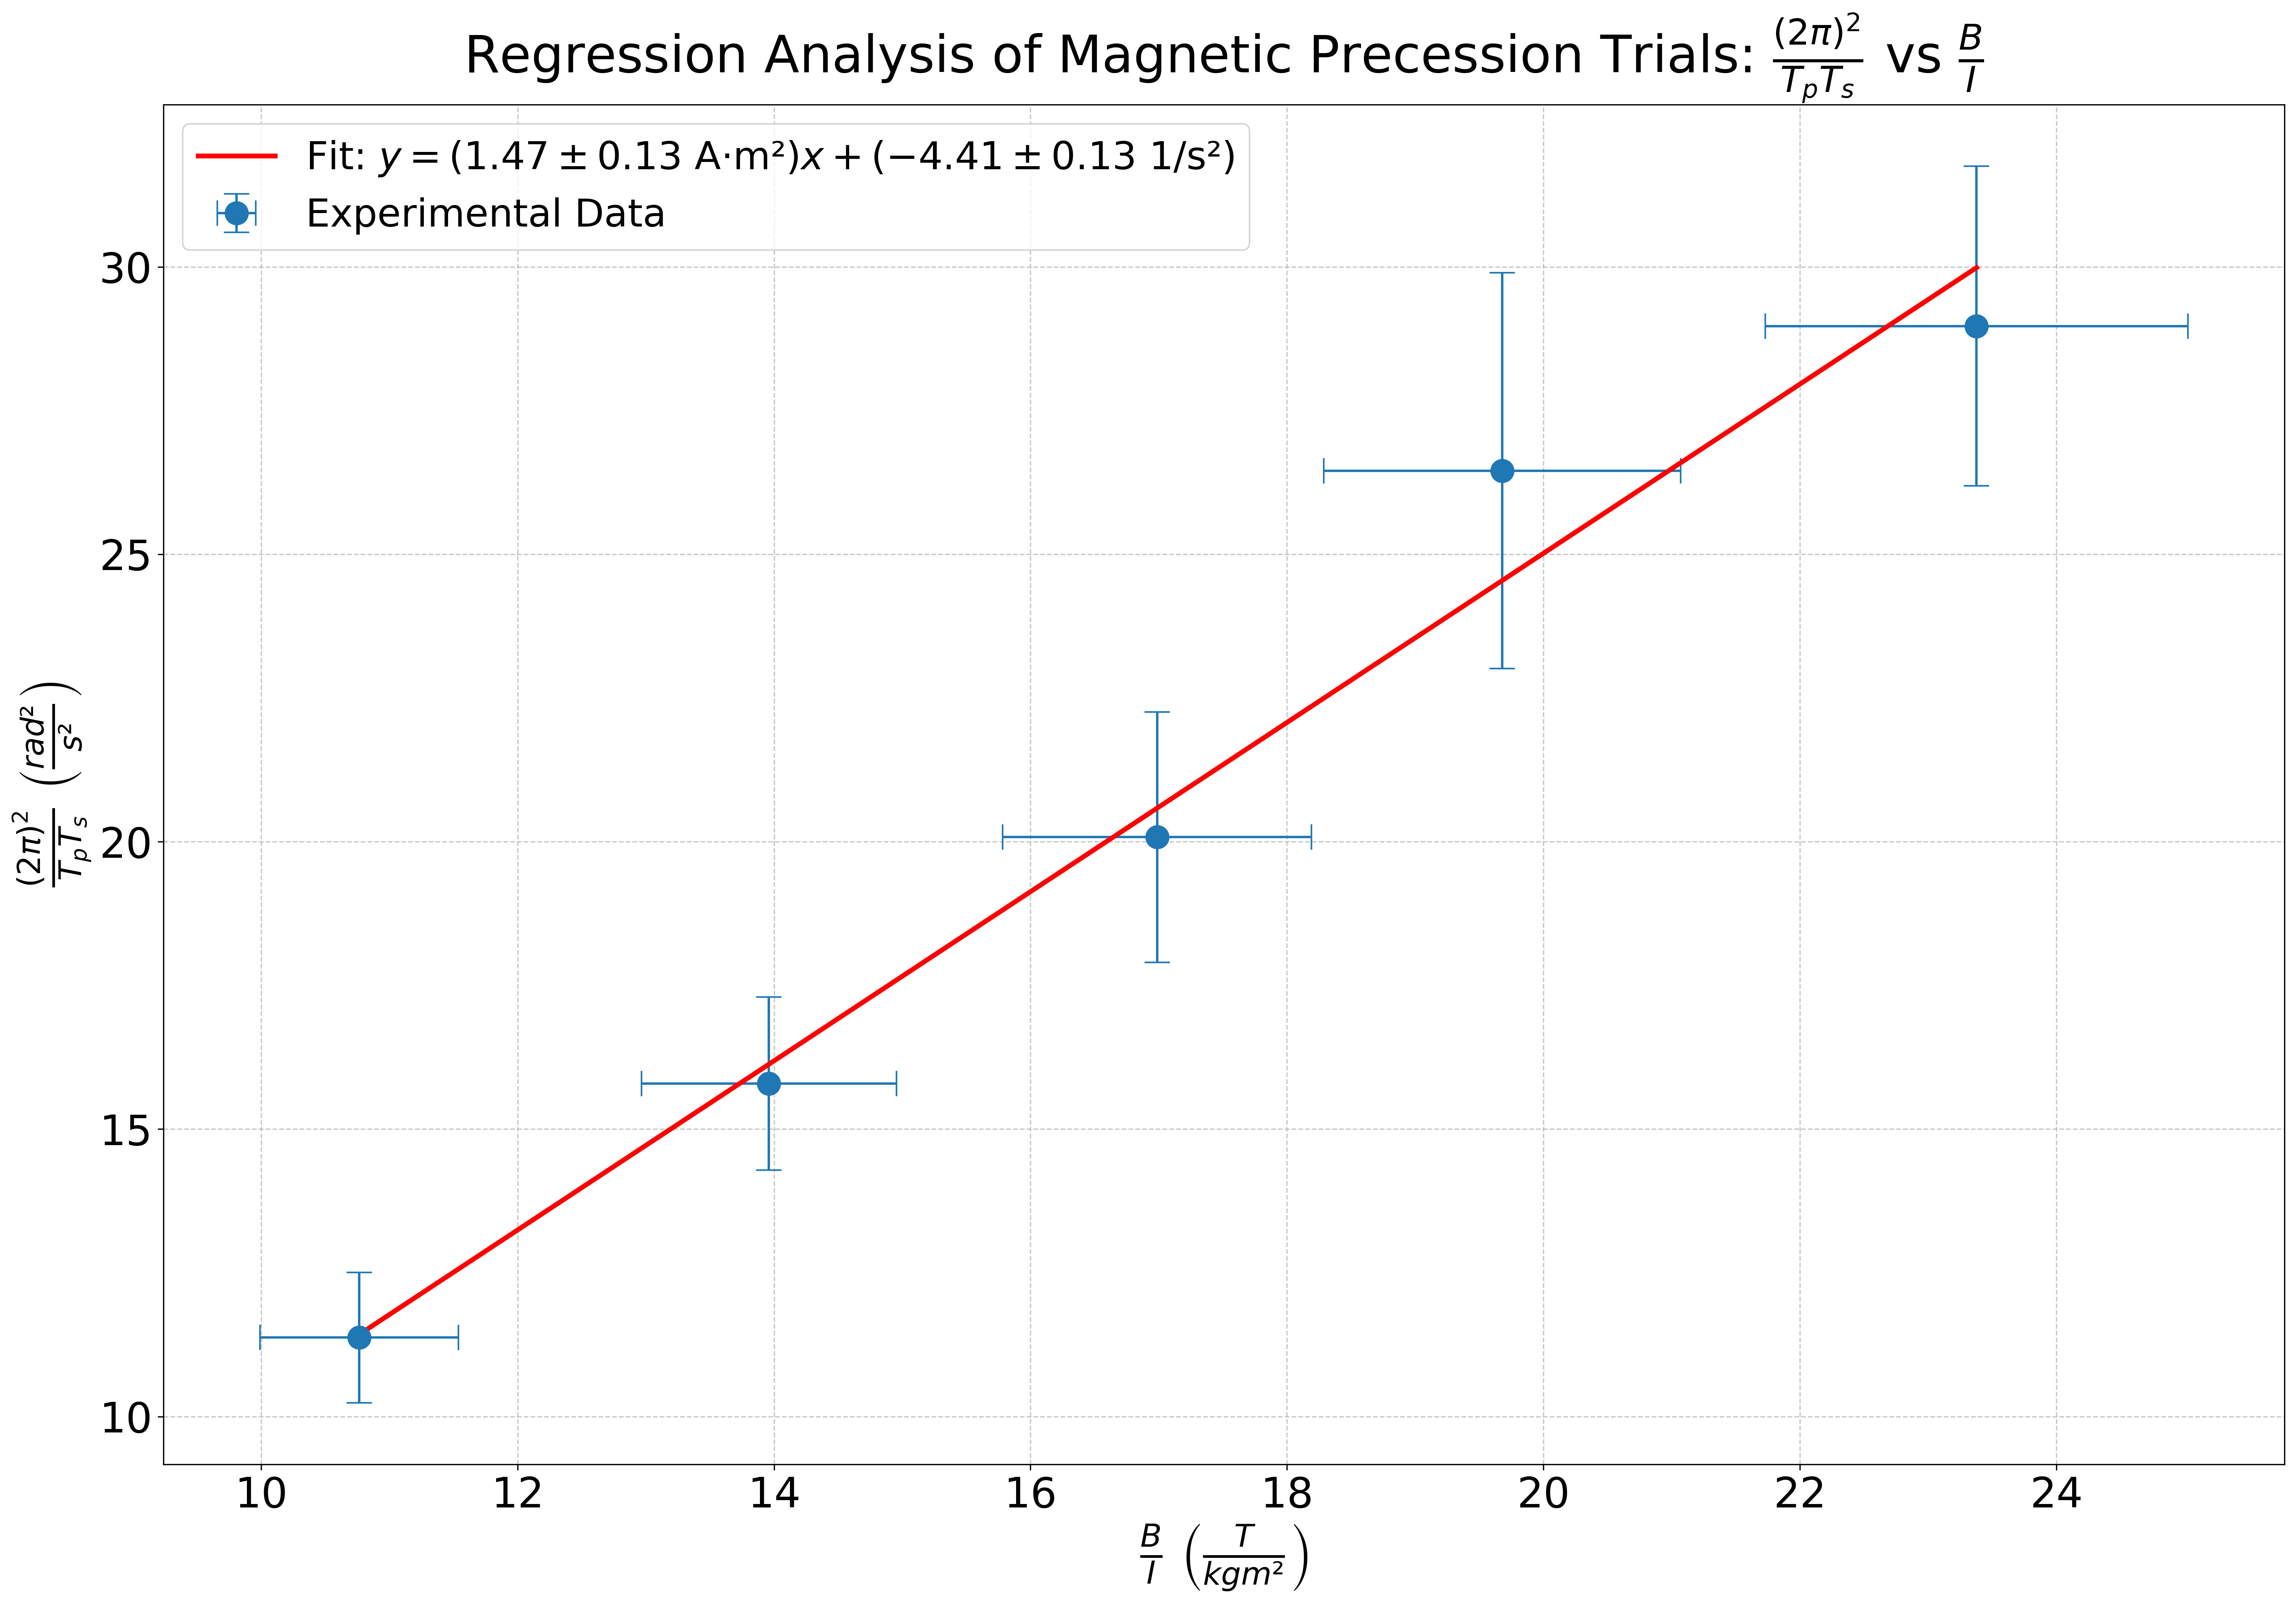

In [55]:
from scipy import stats

plt.figure(figsize=(20, 14), dpi=300)  # Increased figure size and resolution

plt.errorbar(
    df["B_upon_I"],
    df["2_pi_upon_Tp_Ts_sq"],
    xerr=df["B_upon_I_unc"],
    yerr=df["2_pi_upon_Tp_Ts_sq_unc"],
    fmt="o",
    capsize=8,
    label="Experimental Data",
    markersize=14,  # Increased marker size
)

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df["B_upon_I"], df["2_pi_upon_Tp_Ts_sq"]
)
print("Slope:", slope)
print("Intercept:", intercept)
print("R-value:", r_value)
print("P-value:", p_value)
print("Standard Error:", std_err)

x_line = np.linspace(df["B_upon_I"].min(), df["B_upon_I"].max(), 100)
y_line = slope * x_line + intercept

plt.plot(x_line, y_line, "r-", label="Linear Regression", linewidth=3)

slope_rounded, slope_unc_rounded = round_unc(slope, std_err)
intercept_rounded, intercept_unc_rounded = round_unc(intercept, std_err)

plt.title(
    rf"Regression Analysis of Magnetic Precession Trials: $\frac{{(2\pi)^2}}{{T_p T_s}}$ vs $\frac{{B}}{{I}}$",
    fontsize=32,  # Increased title font size
)
plt.xlabel(
    rf"$\frac{{B}}{{I}}$ $\left (\frac{{T}}{{kg m²}}\right)$", fontsize=28
)  # Increased x-label font size
plt.ylabel(
    rf"$\frac{{(2\pi)^2}}{{T_p T_s}}$ $\left (\frac{{rad²}}{{s²}}\right)$",
    fontsize=28,  # Increased y-label font size
)
plt.legend(
    [
        rf"Fit: $y = ({slope_rounded} \pm {slope_unc_rounded} \text{{ A·m²}})x + ({intercept_rounded} \pm {intercept_unc_rounded} \text{{ 1/s²}})$",
        "Experimental Data",
    ],
    fontsize=24,  # Increased legend font size
    loc="best",
)

plt.tick_params(axis="both", which="major", labelsize=26)  # Increased tick label size
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(
    "magnetic_precession_trials.png", dpi=400
)  # Further increased save resolution
plt.show()

# Table Formatting for Report


In [56]:
report_df = pd.DataFrame()

PREC_PER_UNC = 1  # s

report_df["pos_current"] = df["pos_current"]
reported_sho_period, reported_sho_period_unc = round_unc(
    df["sho_period_avg"], df["sho_period_unc"]
)
report_df["sho_period"] = reported_sho_period
report_df["sho_period_unc"] = reported_sho_period_unc
reported_spin_period, reported_spin_period_unc = round_unc(
    df["spin_period_avg"], df["spin_period_unc"]
)
report_df["spin_period"] = reported_spin_period
report_df["spin_period_unc"] = reported_spin_period_unc

reported_prec_period, reported_prec_period_unc = round_unc(
    df["precession_period"], PREC_PER_UNC
)
report_df["precession_period"] = reported_prec_period
reported_field, reported_field_unc = round_unc(df["magnetic_field_T"], B_unc)
report_df["magnetic_field"] = reported_field
print(reported_field_unc)
# report_df["magnetic_field_unc"] = reported_field_unc

report_df

[1.e-05]


,pos_current,sho_period,sho_period_unc,spin_period,spin_period_unc,precession_period,magnetic_field
0,2.00,1.020,0.009,0.0590,0.0012,23.1,0.00139
1,1.75,1.134,0.015,0.0620,0.0030,24.2,0.00117
2,1.50,1.221,0.016,0.0646,0.0028,30.4,0.00101
3,1.25,1.365,0.022,0.0578,0.0024,43.2,0.00083
4,1.00,1.502,0.008,0.0740,0.0030,46.9,0.00064


In [57]:
report_df["magnetic_field"]

0    0.00139
1    0.00117
2    0.00101
3    0.00083
4    0.00064
Name: magnetic_field, dtype: float64

In [58]:
report_df.to_markdown()

'|    |   pos_current |   sho_period |   sho_period_unc |   spin_period |   spin_period_unc |   precession_period |   magnetic_field |\n|---:|--------------:|-------------:|-----------------:|--------------:|------------------:|--------------------:|-----------------:|\n|  0 |          2    |        1.02  |            0.009 |        0.059  |            0.0012 |                23.1 |          0.00139 |\n|  1 |          1.75 |        1.134 |            0.015 |        0.062  |            0.003  |                24.2 |          0.00117 |\n|  2 |          1.5  |        1.221 |            0.016 |        0.0646 |            0.0028 |                30.4 |          0.00101 |\n|  3 |          1.25 |        1.365 |            0.022 |        0.0578 |            0.0024 |                43.2 |          0.00083 |\n|  4 |          1    |        1.502 |            0.008 |        0.074  |            0.003  |                46.9 |          0.00064 |'

In [59]:
df["mu_sho_unc"]

0    0.118143
1    0.118226
2    0.117841
3    0.118126
4    0.118180
Name: mu_sho_unc, dtype: float64

In [60]:
pointwise_df = pd.DataFrame()
pointwise_df["pos_current"] = report_df["pos_current"]

mu_sho_pw, mu_sho_pw_unc = round_unc(df["mu_sho"], df["mu_sho_unc"])
pointwise_df["mu_sho"] = mu_sho_pw
pointwise_df["mu_sho_unc"] = mu_sho_pw_unc

mu_prec_pw, mu_prec_pw_unc = round_unc(df["mu_prec"], df["mu_prec_unc"])
pointwise_df["mu_prec"] = mu_prec_pw
pointwise_df["mu_prec_unc"] = mu_prec_pw_unc

pointwise_df.to_markdown()

'|    |   pos_current |   mu_sho |   mu_sho_unc |   mu_prec |   mu_prec_unc |\n|---:|--------------:|---------:|-------------:|----------:|--------------:|\n|  0 |          2    |     1.62 |         0.12 |      1.24 |          0.15 |\n|  1 |          1.75 |     1.56 |         0.12 |      1.34 |          0.2  |\n|  2 |          1.5  |     1.56 |         0.12 |      1.18 |          0.15 |\n|  3 |          1.25 |     1.52 |         0.12 |      1.13 |          0.13 |\n|  4 |          1    |     1.63 |         0.12 |      1.06 |          0.13 |'

In [61]:
pointwise_df

,pos_current,mu_sho,mu_sho_unc,mu_prec,mu_prec_unc
0,2.00,1.62,0.12,1.24,0.15
1,1.75,1.56,0.12,1.34,0.20
2,1.50,1.56,0.12,1.18,0.15
3,1.25,1.52,0.12,1.13,0.13
4,1.00,1.63,0.12,1.06,0.13
